In [1]:
import pandas as pd
import numpy as np
import sqlite3

# Connexion à la base
conn = sqlite3.connect("../data/processed/market_data.db")

# Charger les données
fx_df  = pd.read_sql("SELECT * FROM fx_daily", conn, index_col="date", parse_dates=["date"])
eq_df  = pd.read_sql("SELECT * FROM equities_daily", conn, index_col="date", parse_dates=["date"])
rat_df = pd.read_sql("SELECT * FROM rates_daily", conn, index_col="date", parse_dates=["date"])

# Calcul des returns journaliers
fx_ret  = fx_df.pct_change().dropna()
eq_ret  = eq_df.pct_change().dropna()

print("✅ Returns calculés")
print(fx_ret.tail(3))


✅ Returns calculés
              eurusd    usdjpy
date                          
2024-12-26 -0.000291  0.000165
2024-12-27  0.002272  0.003914
2024-12-30  0.000594  0.000792


In [2]:
def sharpe_ratio(returns, rf=0.05/252):
    excess = returns - rf
    return (excess.mean() / returns.std()) * np.sqrt(252)

def max_drawdown(prices):
    roll_max = prices.cummax()
    drawdown = (prices - roll_max) / roll_max
    return drawdown.min()

def parametric_var(returns, confidence=0.95):
    return returns.mean() - returns.std() * 1.645

print("✅ Fonctions définies")


✅ Fonctions définies


In [3]:
assets = {
    "EUR/USD" : fx_ret["eurusd"],
    "USD/JPY" : fx_ret["usdjpy"],
    "SPY"     : eq_ret["SPY"],
}

results = []
for name, ret in assets.items():
    results.append({
        "Asset"       : name,
        "Sharpe"      : round(sharpe_ratio(ret), 2),
        "VaR 95%"     : round(parametric_var(ret) * 100, 3),
        "Max Drawdown": round(max_drawdown((1 + ret).cumprod()) * 100, 2),
        "Vol Ann."    : round(ret.std() * np.sqrt(252) * 100, 2),
    })

results_df = pd.DataFrame(results).set_index("Asset")
print(results_df)


         Sharpe  VaR 95%  Max Drawdown  Vol Ann.
Asset                                           
EUR/USD   -0.89   -0.737        -22.24      7.06
USD/JPY    0.14   -0.887        -14.75      8.80
SPY        0.65   -1.985        -33.72     19.84


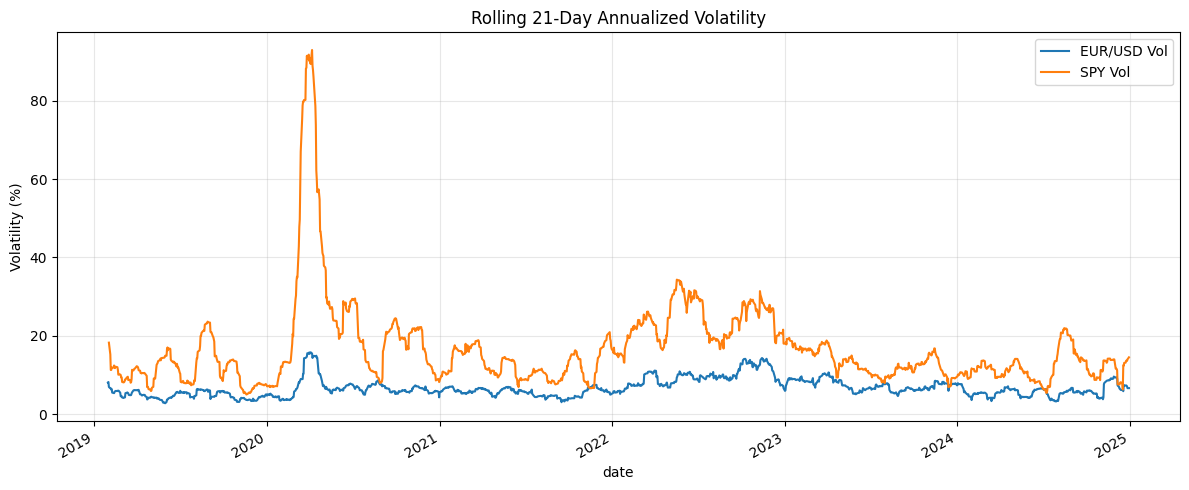

✅ Chart sauvegardé


In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

(fx_ret["eurusd"].rolling(21).std() * np.sqrt(252) * 100).plot(ax=ax, label="EUR/USD Vol")
(eq_ret["SPY"].rolling(21).std() * np.sqrt(252) * 100).plot(ax=ax, label="SPY Vol")

ax.set_title("Rolling 21-Day Annualized Volatility")
ax.set_ylabel("Volatility (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../output/charts/rolling_vol.png", dpi=150)
plt.show()
print("✅ Chart sauvegardé")


/var/folders/fs/g25v0c6d1z3_smjb528zwj0h0000gn/T/ipykernel_47450/4170672976.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  all_ret = pd.concat([


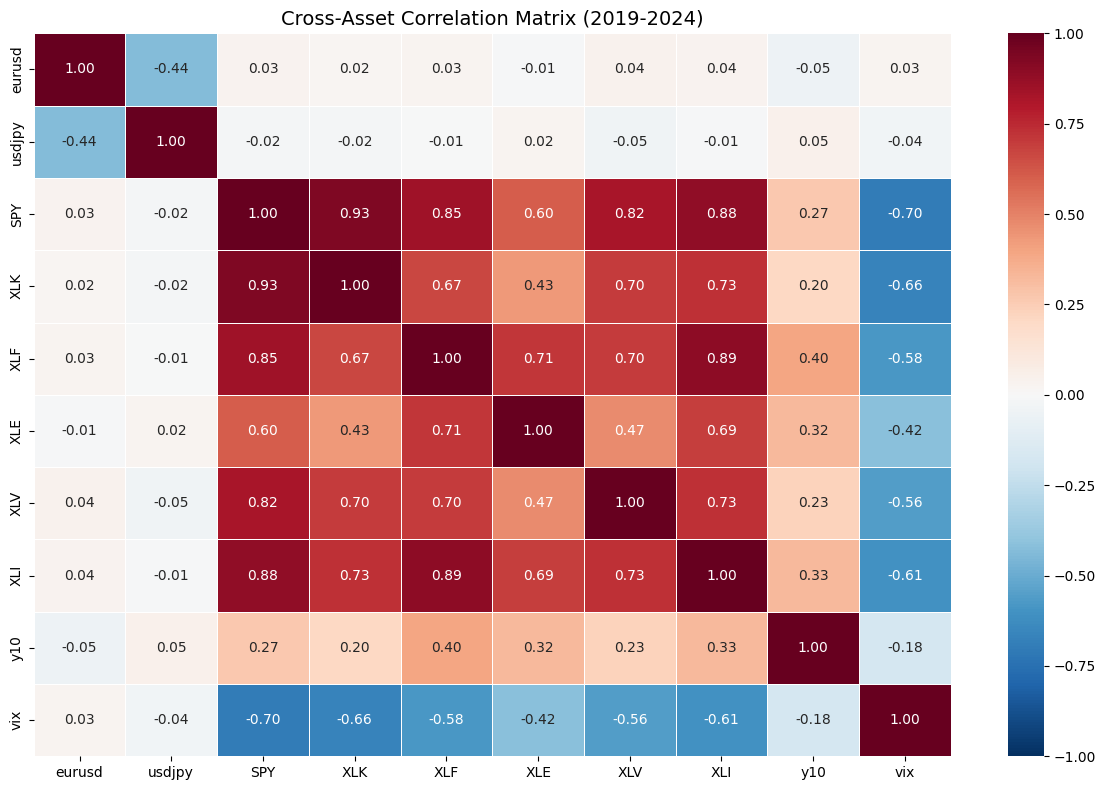

✅ Heatmap sauvegardée


In [7]:
import seaborn as sns

# Combiner tous les returns en un seul DataFrame
all_ret = pd.concat([
    fx_ret[["eurusd", "usdjpy"]],
    eq_ret[["SPY", "XLK", "XLF", "XLE", "XLV", "XLI"]],
    rat_df[["y10", "vix"]].pct_change().dropna()
], axis=1).dropna()

# Matrice de corrélation
corr = all_ret.corr()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5
)
ax.set_title("Cross-Asset Correlation Matrix (2019-2024)", fontsize=14)
plt.tight_layout()
plt.savefig("../output/charts/correlation_heatmap.png", dpi=150)
plt.show()
print("✅ Heatmap sauvegardée")


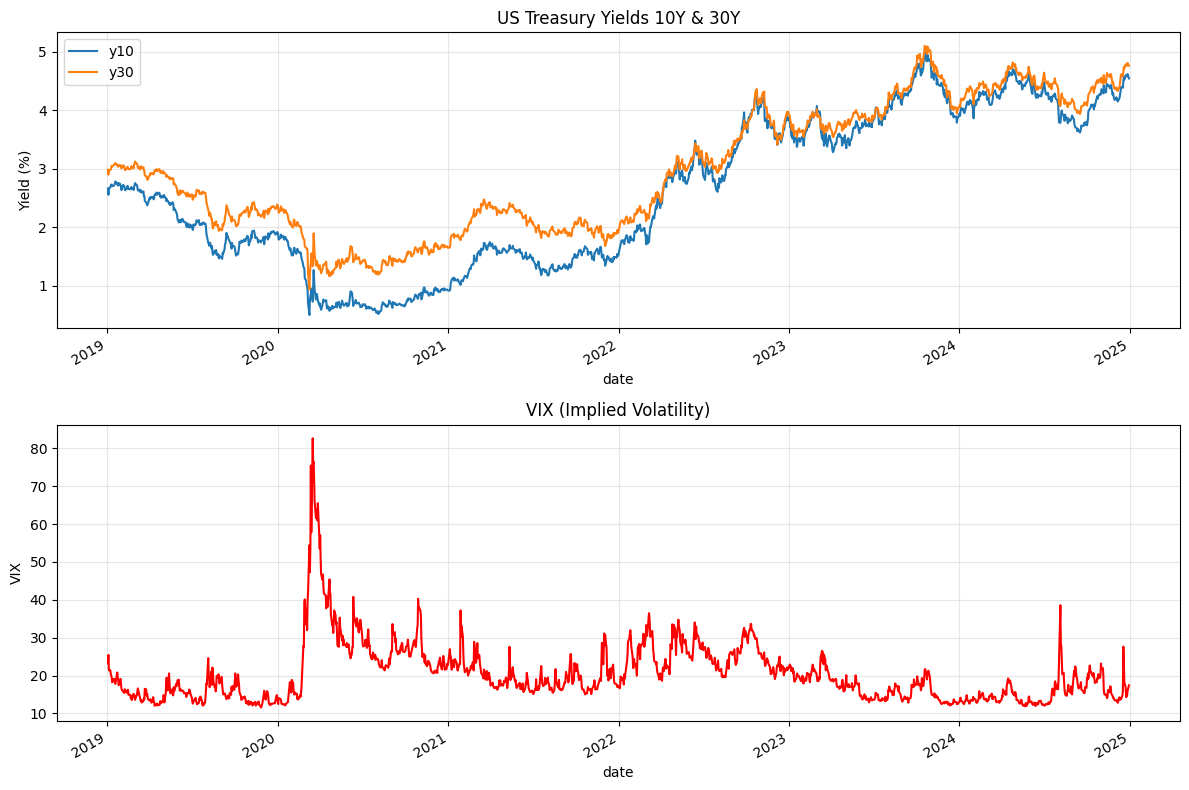

✅ Chart rates sauvegardé


In [8]:
# Evolution du spread 2s10s (bear steepening / flattening)
rat_df["spread_2s10s"] = rat_df["y10"] - rat_df["y10"].shift(1)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Panel 1 : Taux 10Y et 30Y
rat_df[["y10", "y30"]].plot(ax=axes[0], title="US Treasury Yields 10Y & 30Y")
axes[0].set_ylabel("Yield (%)")
axes[0].grid(True, alpha=0.3)

# Panel 2 : VIX
rat_df["vix"].plot(ax=axes[1], color="red", title="VIX (Implied Volatility)")
axes[1].set_ylabel("VIX")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../output/charts/rates_vix.png", dpi=150)
plt.show()
print("✅ Chart rates sauvegardé")
